# Data Loader Checks

In [1]:
# need to check data quality

import pandas as pd
from pathlib import Path

data_path = Path("..") / "data" / "prices_raw.csv"
prices = pd.read_csv(data_path)
prices["Date"] = pd.to_datetime(prices["Date"])
prices = prices.set_index(["Date", "Ticker"]).sort_index()
prices.head(10)


adj close       close        high         low        open  \
Date       Ticker                                                              
2015-11-30 A       38.576069   41.820000   42.049999   41.610001   41.970001   
           AAPL    26.672974   29.575001   29.852501   29.437500   29.497499   
           ABBV    38.367210   58.150002   60.209999   57.959999   59.959999   
           ABNB          NaN         NaN         NaN         NaN         NaN   
           ABT     37.207771   44.919998   45.540001   44.919998   45.439999   
           ACGL    22.970539   24.156668   24.450001   24.123333   24.293333   
           ACN     91.546249  107.220001  107.790001  107.099998  107.580002   
           ADBE    91.459999   91.459999   92.660004   91.129997   92.410004   
           ADI     50.245872   61.630001   62.080002   60.389999   60.389999   
           ADM     27.079082   36.490002   36.619999   36.099998   36.529999   

                        volume  
Date       Ticker               
2015-11-30 A         3208100.0  
           AAPL    156721200.0  
           ABBV     12660200.0  
           ABNB            NaN  
           ABT       7827000.0  
           ACGL      3369600.0  
           ACN       2868800.0  
           ADBE      2380200.0  
           ADI       3358100.0  
           ADM       6508100.0

In [2]:
prices.index.get_level_values("Ticker").unique()


Index(['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM',
       ...
       'WY', 'WYNN', 'XEL', 'XOM', 'XYL', 'XYZ', 'YUM', 'ZBH', 'ZBRA', 'ZTS'],
      dtype='object', name='Ticker', length=503)

In [3]:
prices.index.get_level_values("Date").min(), prices.index.get_level_values("Date").max()


(Timestamp('2015-11-30 00:00:00'), Timestamp('2025-11-28 00:00:00'))

In [4]:
prices.isna().mean().sort_values(ascending=False).head(10)


adj close    0.031485
close        0.031485
high         0.031485
low          0.031485
open         0.031485
volume       0.031485
dtype: float64

In [5]:
prices.index.duplicated().any()


np.False_

In [6]:
(prices[["open","high","low","close","adj close","volume"]] <= 0).any()


open         False
high         False
low          False
close        False
adj close    False
volume        True
dtype: bool

In [7]:
bad_high = (prices["high"] < prices[["open","close"]].max(axis=1)).mean()
bad_low  = (prices["low"]  > prices[["open","close"]].min(axis=1)).mean()
bad_high, bad_low


(np.float64(7.904857139469347e-07), np.float64(1.5809714278938694e-06))

In [8]:
prices.groupby("Ticker").apply(lambda x: x.index.get_level_values("Date").is_monotonic_increasing).all()


np.True_

In [9]:
prices.index.get_level_values("Date").min(), prices.index.get_level_values("Date").max()


(Timestamp('2015-11-30 00:00:00'), Timestamp('2025-11-28 00:00:00'))

In [10]:
prices.groupby("Ticker").apply(lambda x: x.isna().mean().mean()).describe()


count    503.000000
mean       0.031485
std        0.134769
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.990457
dtype: float64

In [11]:
prices.index.get_level_values("Ticker").nunique()


503

# Feature Engineering Checks

In [12]:
import pandas as pd

data = pd.read_csv(
    "../data/modeling_data.csv",
    parse_dates=["Date"],
    index_col=["Date", "Ticker"],
)

data.info()
data.head()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 9330 entries, (Timestamp('2018-10-31 00:00:00'), 'AAPL') to (Timestamp('2025-11-30 00:00:00'), 'XOM')
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   gkv         9330 non-null   float64
 1   rsi         9330 non-null   float64
 2   bblow       9330 non-null   float64
 3   bbmid       9330 non-null   float64
 4   bbhigh      9330 non-null   float64
 5   atr         9330 non-null   float64
 6   macd        9330 non-null   float64
 7   dv_rank     9330 non-null   float64
 8   return_1m   9330 non-null   float64
 9   return_2m   9330 non-null   float64
 10  return_3m   9330 non-null   float64
 11  return_6m   9330 non-null   float64
 12  return_9m   9330 non-null   float64
 13  return_12m  9330 non-null   float64
 14  beta_mkt    9330 non-null   float64
 15  beta_smb    9330 non-null   float64
 16  beta_hml    9330 non-null   float64
 17  beta_rmw    9330 non-null   flo

gkv       rsi     bblow     bbmid    bbhigh       atr  \
Date       Ticker                                                               
2018-10-31 AAPL    0.706710  0.428258 -0.299040 -0.356786 -0.414075 -0.364661   
           ABBV   -1.470151 -1.578240 -0.154979 -0.111582 -0.067179 -0.157228   
           ABT     0.475714  0.547928 -0.121088 -0.172918 -0.224862 -0.371405   
           AMGN   -0.021912 -0.139004  0.941959  0.927705  0.909954  0.314475   
           AMZN    0.765557 -0.703686  0.195197  0.242744  0.290097  0.111763   

                       macd   dv_rank  return_1m  return_2m  return_3m  \
Date       Ticker                                                        
2018-10-31 AAPL    0.542633 -1.434069  -0.030478  -0.019453   0.048955   
           ABBV   -0.149205 -0.107818  -0.168082  -0.087312  -0.051576   
           ABT     0.536632  0.362787  -0.056387   0.017673   0.018393   
           AMGN   -0.188720 -0.364512  -0.069950  -0.017724  -0.004169   
           AMZN   -0.619396 -1.455460  -0.202192  -0.108956  -0.034850   

                   return_6m  return_9m  return_12m  beta_mkt  beta_smb  \
Date       Ticker                                                         
2018-10-31 AAPL     0.049216   0.031518    0.023037  1.033251 -0.838262   
           ABBV    -0.031893  -0.035621   -0.009087  0.900583 -0.918223   
           ABT      0.030307   0.013075    0.021747  0.124178 -0.083654   
           AMGN     0.019226   0.006419    0.010418  0.263601 -0.219799   
           AMZN     0.003364   0.010789    0.031198  0.560871  0.464198   

                   beta_hml  beta_rmw  beta_cma  
Date       Ticker                                
2018-10-31 AAPL    0.546052 -1.492379  0.871802  
           ABBV    0.388793 -0.307313  0.037730  
           ABT     0.059018  0.205755 -0.233019  
           AMGN   -0.432507 -0.434231  0.500253  
           AMZN    0.394348  0.352518 -0.078888

In [13]:
expected_cols = [
    "gkv",
    "rsi",
    "bblow",
    "bbmid",
    "bbhigh",
    "atr",
    "macd",
    "dv_rank",
    "return_1m",
    "return_2m",
    "return_3m",
    "return_6m",
    "return_9m",
    "return_12m",
    "beta_mkt",
    "beta_smb",
    "beta_hml",
    "beta_rmw",
    "beta_cma",
]

missing = set(expected_cols) - set(data.columns)
extra = set(data.columns) - set(expected_cols)

print("Missing:", missing)
print("Extra:", extra)


Missing: set()
Extra: set()


In [14]:
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())


Shape: (9330, 19)
Columns: ['gkv', 'rsi', 'bblow', 'bbmid', 'bbhigh', 'atr', 'macd', 'dv_rank', 'return_1m', 'return_2m', 'return_3m', 'return_6m', 'return_9m', 'return_12m', 'beta_mkt', 'beta_smb', 'beta_hml', 'beta_rmw', 'beta_cma']


In [15]:
data.isna().sum().sort_values(ascending=False)


gkv           0
return_3m     0
beta_rmw      0
beta_hml      0
beta_smb      0
beta_mkt      0
return_12m    0
return_9m     0
return_6m     0
return_2m     0
rsi           0
return_1m     0
dv_rank       0
macd          0
atr           0
bbhigh        0
bbmid         0
bblow         0
beta_cma      0
dtype: int64

In [16]:
data.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
gkv,-0.067643,0.998261,-7.136403,6.836778
rsi,0.002321,0.980244,-3.995148,4.221576
bblow,-0.005242,1.005280,-3.519384,3.785070
bbmid,-0.008557,1.006994,-3.504893,3.779146
bbhigh,-0.011890,1.008329,-3.487555,3.776965
atr,-0.011931,1.057868,-0.820179,10.263213
macd,0.002457,1.011891,-10.434904,10.601719
dv_rank,-0.293481,0.764045,-1.563830,2.878135
return_1m,0.015742,0.100024,-0.631434,1.771208
return_2m,0.013302,0.068551,-0.369959,0.834536


In [17]:
ret_cols = [c for c in data.columns if "return_" in c]
data[ret_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
return_1m,9330.0,0.015742,0.100024,-0.631434,-0.041987,0.012229,0.068796,1.771208
return_2m,9330.0,0.013302,0.068551,-0.369959,-0.026748,0.011274,0.050421,0.834536
return_3m,9330.0,0.012548,0.055053,-0.301869,-0.018772,0.011009,0.042718,0.500972
return_6m,9330.0,0.011837,0.038335,-0.189237,-0.009410,0.011508,0.032656,0.253883
return_9m,9330.0,0.011362,0.031296,-0.139586,-0.006132,0.011116,0.028449,0.243277
return_12m,9330.0,0.011331,0.026997,-0.118616,-0.003734,0.010931,0.026164,0.210402


In [18]:
ff_cols = ["beta_mkt", "beta_smb", "beta_hml", "beta_rmw", "beta_cma"]
data[ff_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
beta_mkt,9330.0,-0.174306,0.502550,-2.877665,-0.458952,-0.183278,0.104420,2.887110
beta_smb,9330.0,0.490811,0.916818,-4.444833,-0.075862,0.418703,0.977116,7.160256
beta_hml,9330.0,-0.321118,0.847839,-4.905474,-0.756667,-0.230523,0.177726,7.278240
beta_rmw,9330.0,0.412842,1.222996,-8.208216,-0.247360,0.397613,1.002147,13.455000
beta_cma,9330.0,0.473391,1.491439,-4.206709,-0.495831,0.238851,1.201018,14.375456


In [19]:
data.groupby("Date").size().describe()


count     86.000000
mean     108.488372
std       14.263688
min       66.000000
25%       98.250000
50%      114.000000
75%      119.000000
max      130.000000
dtype: float64

In [20]:
import numpy as np 
X = data.values
assert np.isfinite(X).all()


# Clustering Algorithm

In [21]:
import sys
!{sys.executable} -m pip install hdbscan


In [22]:
import sys
from pathlib import Path

SRC_PATH = Path("..") / "src"
sys.path.append(str(SRC_PATH))


In [23]:
CLUSTER_COLS = [
    "gkv", "rsi", "bblow", "bbmid", "bbhigh",
    "atr", "macd", "dv_rank",
    "return_1m", "return_2m", "return_3m",
    "return_6m", "return_9m", "return_12m",
    "beta_mkt", "beta_smb", "beta_hml", "beta_rmw", "beta_cma",
]


In [26]:
modeling_data = pd.read_csv(
    "../data/modeling_data.csv",
    parse_dates=["Date"]
)

modeling_data = (
    modeling_data
    .set_index(["Date", "Ticker"])
    .sort_index()
    .reset_index()   # <-- important for groupby("Date")
)

In [ ]:
from clustering import kmeans_clustering

clustered_df = kmeans_clustering(
    data=modeling_data,
    feature_cols=CLUSTER_COLS,
    n_clusters=5,
)


In [33]:
clustered_df.head()

,Date,Ticker,gkv,rsi,bblow,bbmid,bbhigh,atr,macd,dv_rank,...,return_3m,return_6m,return_9m,return_12m,beta_mkt,beta_smb,beta_hml,beta_rmw,beta_cma,cluster
0,2018-10-31,AAPL,0.706710,0.428258,-0.299040,-0.356786,-0.414075,-0.364661,0.542633,-1.434069,...,0.048955,0.049216,0.031518,0.023037,1.033251,-0.838262,0.546052,-1.492379,0.871802,1
1,2018-10-31,ABBV,-1.470151,-1.578240,-0.154979,-0.111582,-0.067179,-0.157228,-0.149205,-0.107818,...,-0.051576,-0.031893,-0.035621,-0.009087,0.900583,-0.918223,0.388793,-0.307313,0.037730,0
2,2018-10-31,ABT,0.475714,0.547928,-0.121088,-0.172918,-0.224862,-0.371405,0.536632,0.362787,...,0.018393,0.030307,0.013075,0.021747,0.124178,-0.083654,0.059018,0.205755,-0.233019,1
3,2018-10-31,AMGN,-0.021912,-0.139004,0.941959,0.927705,0.909954,0.314475,-0.188720,-0.364512,...,-0.004169,0.019226,0.006419,0.010418,0.263601,-0.219799,-0.432507,-0.434231,0.500253,2
4,2018-10-31,AMZN,0.765557,-0.703686,0.195197,0.242744,0.290097,0.111763,-0.619396,-1.455460,...,-0.034850,0.003364,0.010789,0.031198,0.560871,0.464198,0.394348,0.352518,-0.078888,0


In [37]:
cluster_means = (
    clustered_df
    .groupby("cluster")[CLUSTER_COLS]
    .mean()
)
cluster_means

,gkv,rsi,bblow,bbmid,bbhigh,atr,macd,dv_rank,return_1m,return_2m,return_3m,return_6m,return_9m,return_12m,beta_mkt,beta_smb,beta_hml,beta_rmw,beta_cma
cluster,,,,,,,,,,,,,,,,,,,
0,-0.130819,-0.026164,-0.206591,-0.209336,-0.211435,-0.141233,-0.028121,-0.264709,0.010674,0.013346,0.011660,0.011283,0.009691,0.009469,-0.203576,0.679670,-0.397200,0.601063,0.522560
1,-0.039882,0.008606,0.065563,0.061147,0.056399,-0.043256,0.002147,-0.313418,0.020786,0.015528,0.014329,0.012870,0.012320,0.011899,-0.179198,0.487133,-0.312339,0.503420,0.519587
2,0.078525,0.023497,0.180982,0.177014,0.172648,0.088164,0.050173,-0.317708,0.014492,0.010575,0.009630,0.010346,0.011163,0.011595,-0.142371,0.412502,-0.290670,0.327936,0.441615
3,-0.238756,0.044102,-0.092043,-0.095343,-0.098681,-0.014287,0.068171,-0.229768,0.019507,0.018168,0.014898,0.014110,0.013364,0.012855,-0.148336,0.441862,-0.308473,0.293239,0.477410
4,-0.026418,-0.038765,0.041712,0.040337,0.038956,0.124504,-0.089461,-0.344815,0.012894,0.007611,0.012443,0.010504,0.010513,0.011393,-0.191426,0.341604,-0.264481,0.184935,0.346660


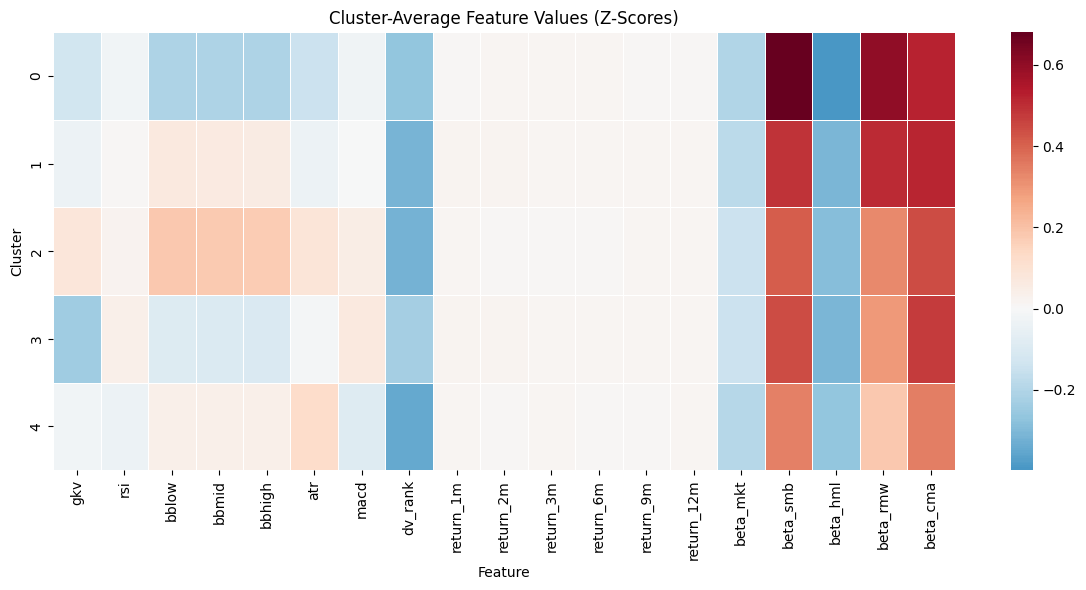

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_means,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Cluster-Average Feature Values (Z-Scores)")
plt.ylabel("Cluster")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()


### Interpretation of Cluster Characteristics

The heatmap of cluster-average feature values highlights economically distinct regimes that stocks tend to occupy over time.

- **Cluster 0 — Defensive / Low Momentum**  
  Characterized by below-average momentum indicators and muted return signals. Stocks in this cluster tend to exhibit lower growth characteristics and behave defensively relative to the cross-section.

- **Cluster 1 — Momentum–Quality Hybrid**  
  Displays consistently positive return measures alongside favorable profitability and investment factor exposures. This cluster reflects stable, high-quality stocks with persistent momentum.

- **Cluster 2 — Growth / Volatility-Adjusted Momentum**  
  Exhibits elevated volatility and trend indicators with balanced factor loadings. Stocks in this cluster often reflect growth-oriented names with moderate risk.

- **Cluster 3 — Trend-Following Regime**  
  Shows strong momentum signals with moderate volatility and factor exposure. This cluster captures stocks benefiting from sustained price trends.

- **Cluster 4 — High Volatility / Noisy Regime**  
  Marked by elevated volatility and weaker momentum signals. Stocks in this cluster tend to be unstable and less predictable, making them less attractive for momentum-based strategies.

Overall, the heatmap confirms that clustering separates the cross-section into interpretable regimes based on momentum, risk, and factor characteristics, providing a structured foundation for regime-based stock selection.


In [40]:
months = sorted(clustered_df["Date"].unique())

monthly_cluster_means = {
    m: (
        clustered_df[clustered_df["Date"] == m]
        .groupby("cluster")[CLUSTER_COLS]
        .mean()
    )
    for m in months
}


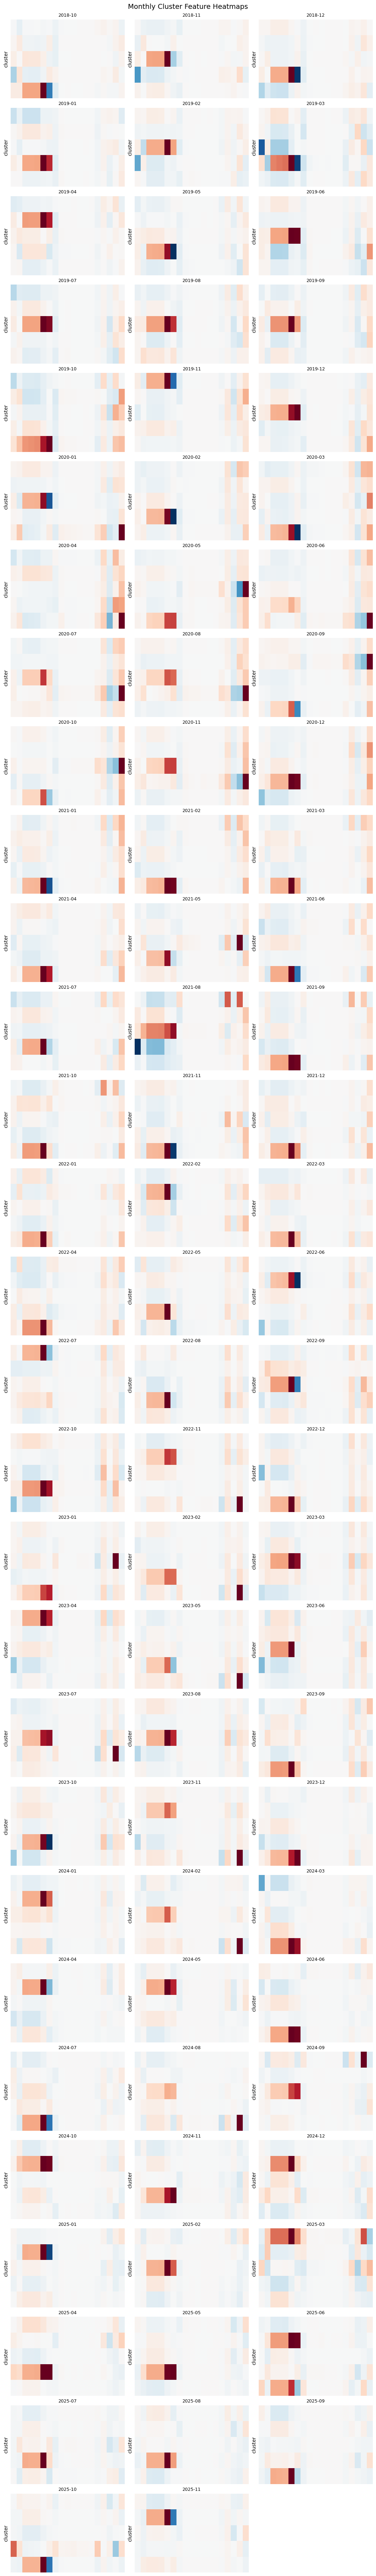

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

n_cols = 3                      # adjust (3–4 works well)
n_rows = int(np.ceil(len(months) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.5 * n_cols, 2.5 * n_rows),
    constrained_layout=True
)

axes = axes.flatten()

for ax, month in zip(axes, months):
    sns.heatmap(
        monthly_cluster_means[month],
        cmap="RdBu_r",
        center=0,
        cbar=False,             # critical: no colorbar per plot
        xticklabels=False,
        yticklabels=False,
        ax=ax
    )
    ax.set_title(month.strftime("%Y-%m"), fontsize=9)

# remove empty axes
for ax in axes[len(months):]:
    ax.axis("off")

plt.suptitle("Monthly Cluster Feature Heatmaps", fontsize=14)
plt.show()


In [43]:
eval_df = clustered_df.copy()

eval_df = eval_df.sort_values(["Ticker", "Date"])

eval_df["fwd_ret_1m"] = (
    eval_df
    .groupby("Ticker")["return_1m"]
    .shift(-1)
)

cluster_perf = (
    eval_df
    .groupby("cluster")["fwd_ret_1m"]
    .mean()
)


In [45]:
cluster_perf

cluster
0    0.022657
1    0.013459
2    0.018355
3    0.011235
4    0.011068
Name: fwd_ret_1m, dtype: float64

In [46]:
cluster_stats = (
    eval_df
    .groupby("cluster")["fwd_ret_1m"]
    .agg(["mean", "std", "count"])
)
cluster_stats


,mean,std,count
cluster,,,
0,0.022657,0.105230,2215
1,0.013459,0.094909,2348
2,0.018355,0.101503,1869
3,0.011235,0.098308,1457
4,0.011068,0.096075,1267


In [47]:
win_rate = (
    eval_df
    .assign(win=lambda x: x["fwd_ret_1m"] > 0)
    .groupby("cluster")["win"]
    .mean()
)
win_rate


cluster
0    0.565352
1    0.549153
2    0.570607
3    0.517034
4    0.522239
Name: win, dtype: float64

In [48]:
cluster_stats["sharpe_like"] = (
    cluster_stats["mean"] / cluster_stats["std"]
)
cluster_stats


,mean,std,count,sharpe_like
cluster,,,,
0,0.022657,0.105230,2215,0.215310
1,0.013459,0.094909,2348,0.141807
2,0.018355,0.101503,1869,0.180833
3,0.011235,0.098308,1457,0.114284
4,0.011068,0.096075,1267,0.115196


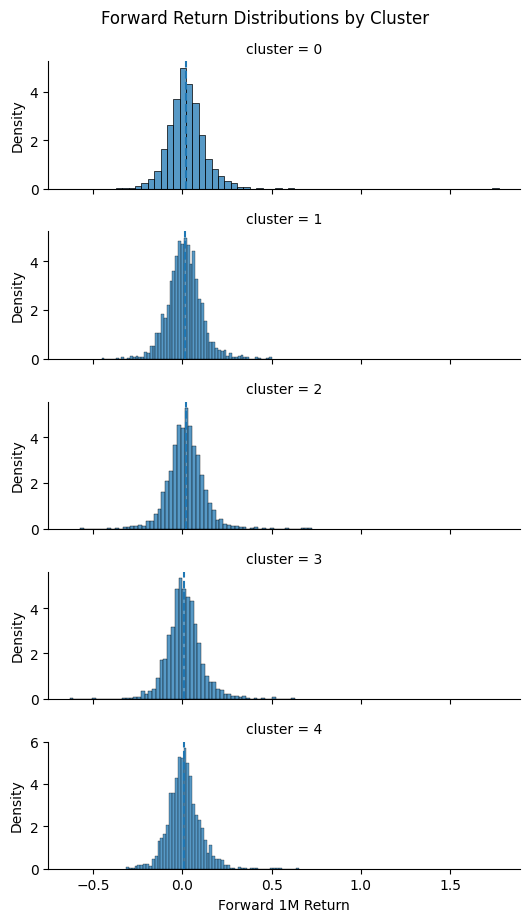

In [51]:
import matplotlib.pyplot as plt

clusters = sorted(eval_df["cluster"].unique())

import seaborn as sns

g = sns.FacetGrid(
    eval_df,
    row="cluster",
    height=1.8,
    aspect=3,
    sharex=True,
    sharey=False
)

g.map(
    sns.histplot,
    "fwd_ret_1m",
    bins=60,
    stat="density"
)

for ax, c in zip(g.axes.flat, sorted(eval_df["cluster"].unique())):
    mean = eval_df.loc[eval_df["cluster"] == c, "fwd_ret_1m"].mean()
    ax.axvline(mean, linestyle="--")

g.set_axis_labels("Forward 1M Return", "Density")
g.fig.suptitle("Forward Return Distributions by Cluster", y=1.02)
plt.show()



Based on forward return analysis, cluster 0 exhibits the highest average next-month returns with volatility comparable to other clusters and a consistently positive win rate. Distributional analysis further shows a positively skewed payoff profile, indicating that cluster 0 captures regimes with superior upside potential. Accordingly, portfolio construction is restricted to assets belonging to cluster 0.